In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/master_ecommerce.csv")

df["order_purchase_timestamp"] = pd.to_datetime(
    df["order_purchase_timestamp"]
)

In [3]:
snapshot_date = (
    df["order_purchase_timestamp"].max() + pd.Timedelta(days = 1)
)

print(snapshot_date)

2018-08-30 15:00:37


In [4]:
rfm = df.groupby("customer_unique_id").agg({
    "order_purchase_timestamp": lambda x: (snapshot_date - x.max()).days,
    
    "order_id": "nunique",
    "payment_value": "sum"
})

In [5]:
rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

rfm.head()

,Recency,Frequency,Monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
0000f46a3911fa3c0805444483337064,537,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
0004aac84e0df4da2b147fca70cf8255,288,1,196.89


In [6]:
rfm.describe()

,Recency,Frequency,Monetary
count,92075.000000,92075.000000,92075.000000
mean,237.194971,1.033093,212.105507
std,152.552404,0.206866,643.647039
min,1.000000,1.000000,9.590000
25%,114.000000,1.000000,63.830000
50%,218.000000,1.000000,112.820000
75%,345.500000,1.000000,202.145000
max,695.000000,14.000000,109312.640000


Recency Score

Lower Recency = Better

In [7]:
rfm["R_Score"] = pd.qcut(rfm["Recency"], 5, labels = [5,4,3,2,1])

Frequency Score

Higher Frequency = Better

In [8]:
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5])

Monetary Score

Higher Spending = Better

In [9]:
rfm["M_Score"] = pd.qcut(rfm["Monetary"], 5, labels=[1,2,3,4,5])

In [10]:
rfm["RFM_Score"] = (rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str))



In [11]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

In [12]:
def segment_customer(row):

    r = row["R_Score"]
    f = row["F_Score"]
    m = row["M_Score"]

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    elif r >= 3 and f >= 3:
        return "Loyal Customers"

    elif r >= 4:
        return "Potential Loyalists"

    elif r <= 2 and f >= 3:
        return "At Risk"

    elif r <= 2 and f <= 2:
        return "Lost Customers"

    else:
        return "Need Attention"
    


In [13]:
rfm["Segment"] = rfm.apply(
    segment_customer,
    axis=1
)

In [14]:
segment_counts = (rfm["Segment"].value_counts().reset_index())

segment_counts

,Segment,count
0,Loyal Customers,27042
1,At Risk,21866
2,Potential Loyalists,14790
3,Lost Customers,14748
4,Need Attention,7292
5,Champions,6337


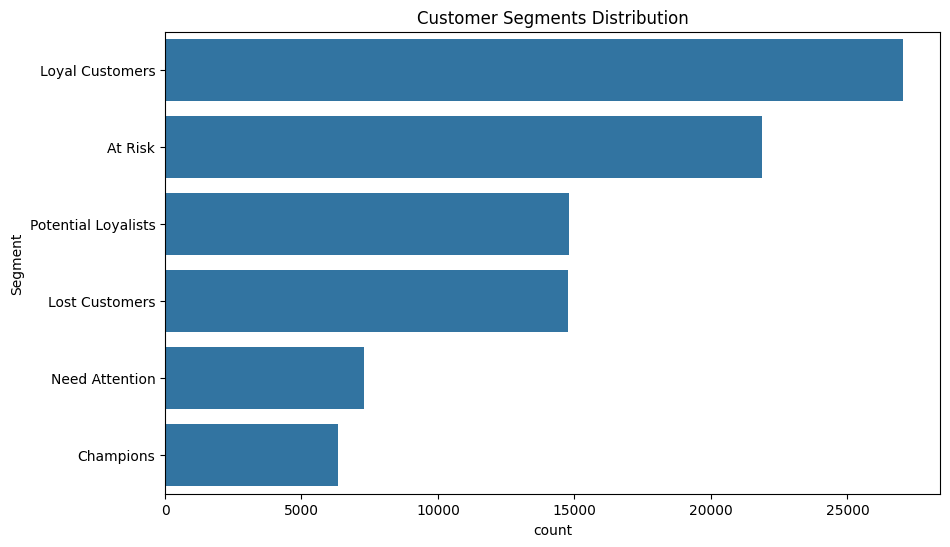

In [15]:
plt.figure(figsize=(10,6))

sns.countplot(
    data = rfm,
    y = "Segment",
    order = rfm["Segment"].value_counts().index
)

plt.title("Customer Segments Distribution")
plt.show()

Customer Segmentation Insights

1. Loyal Customers Form the Largest Segment
Loyal Customers represent the highest customer count.
These customers purchase relatively frequently and have remained engaged with the platform.
They are the most valuable segment for long-term business growth.

Business Action:

Introduce loyalty rewards.
Provide early access to promotions.
Offer personalized recommendations.
2. Large At-Risk Customer Base
The At-Risk segment is the second-largest group.
These customers generated significant revenue historically but have not purchased recently.
There is a high probability of customer churn if no action is taken.

Business Action:

Launch win-back campaigns.
Send personalized discounts.
Use email and push notifications to re-engage customers.
3. Potential Loyalists Present Growth Opportunities
A substantial number of customers fall into the Potential Loyalists segment.
These customers have purchased recently but have not yet become frequent buyers.

Business Action:

Encourage second and third purchases.
Offer targeted cross-selling and upselling opportunities.
Implement onboarding campaigns.
4. Lost Customers Require Reactivation
Lost Customers account for a considerable portion of the customer base.
These customers have not purchased for a long period.

Business Action:

Run reactivation campaigns.
Survey customers to understand churn reasons.
Evaluate whether acquisition costs justify re-engagement efforts.
5. Champions Are a Small but Strategic Group
Champions represent a relatively small customer segment.
Despite their smaller population, they contribute significantly to revenue.

Business Action:

Offer VIP membership programs.
Provide exclusive offers and premium support.
Focus on retention because losing these customers would have a disproportionate revenue impact.

In [16]:
segment_revenue = (
    rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False)
)

segment_revenue

Segment
At Risk                4633610.62
Loyal Customers        4493623.10
Lost Customers         3175404.26
Potential Loyalists    3019343.04
Champions              2814238.66
Need Attention         1393394.86
Name: Monetary, dtype: float64

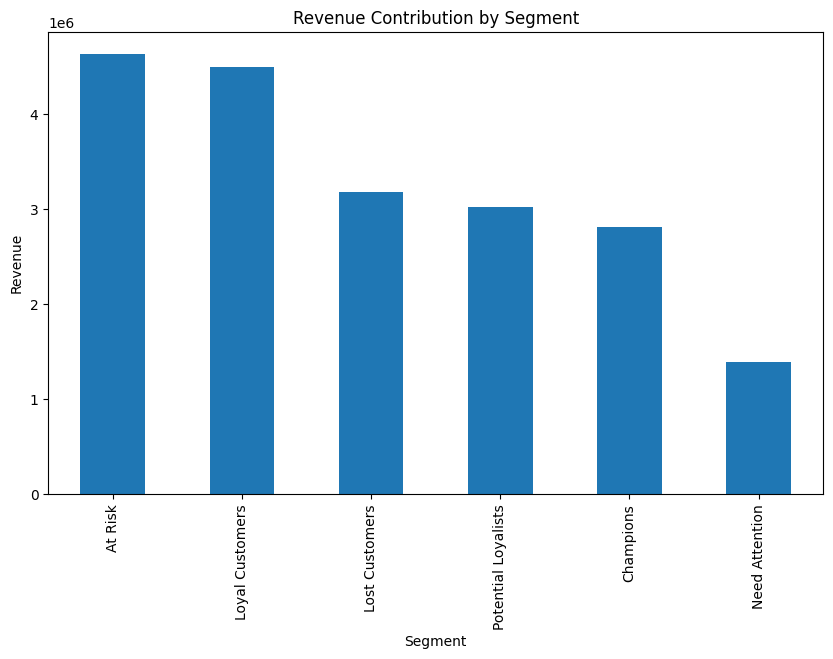

In [17]:
plt.figure(figsize=(10,6))

segment_revenue.plot(kind="bar")

plt.title("Revenue Contribution by Segment")

plt.ylabel("Revenue")
plt.show()

Revenue Contribution Insights

1. At-Risk Customers Generate the Highest Revenue

This is the most important finding in your analysis.

At-Risk customers contribute the largest share of revenue.
A significant amount of business value is currently exposed to churn risk.

Strategic Risk:
If these customers stop purchasing, revenue could decline substantially.

Recommendation:
Prioritize retention campaigns for this segment before investing heavily in acquiring new customers.

2. Loyal Customers Drive Sustainable Revenue
Loyal Customers contribute nearly as much revenue as At-Risk customers.
They represent the healthiest source of recurring business.

Recommendation:
Continue nurturing this segment through loyalty and retention initiatives.

3. Champions Deliver High Value Per Customer

Although Champions are fewer in number:

Their revenue contribution is disproportionately high.
Their average spending is likely much higher than most segments.

Recommendation:
Protect and retain these customers through premium experiences and personalized engagement.

4. Potential Loyalists Offer Future Revenue Growth
Potential Loyalists already generate meaningful revenue.
Converting them into Loyal Customers can significantly increase future revenue.

Recommendation:
Focus marketing efforts on increasing purchase frequency.

Executive Summary

RFM analysis revealed that Loyal Customers constitute the largest customer segment, while At-Risk customers contribute the highest overall revenue. This indicates that a substantial portion of revenue is vulnerable to churn and should be prioritized through targeted retention campaigns. Champions, despite representing a smaller customer base, generate significant revenue and should receive premium engagement strategies. Additionally, Potential Loyalists present strong opportunities for future growth through personalized marketing and loyalty initiatives.

In [18]:
rfm.to_csv("../data/rfm_customers.csv")